<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/lab4aml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import os

In [31]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

image_size = 32
batch_size = 64
nz = 100
num_epochs = 5

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading CIFAR-10...")
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

num_classes = len(dataset.classes)
print(f"Dataset successfully loaded. Classes: {dataset.classes} ({num_classes} total)")

Using device: cuda:0
Dataset successfully loaded. Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] (10 total)


# VAE Implementation (task 1)

In [32]:
class VAE(nn.Module):
  def __init__(self):
    super(VAE, self).__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(3, 32, 4, 2, 1),
        nn.BatchNorm2d(32),
        nn.ReLU(True),
        nn.Conv2d(32, 64, 4, 2, 1),
        nn.BatchNorm2d(64),
        nn.ReLU(True),
        nn.Flatten()
    )

    self.fc_mu = nn.Linear(64 * 8 * 8, nz)
    self.fc_logvar = nn.Linear(64 * 8 * 8, nz)

    self.decoder_input = nn.Linear(nz, 64 * 8 * 8)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(64, 32, 4, 2, 1),
        nn.BatchNorm2d(32),
        nn.ReLU(True),
        nn.ConvTranspose2d(32, 3, 4, 2, 1),
        nn.Tanh()
    )

  def encode(self, x):
    h = self.encoder(x)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h = self.decoder_input(z).view(-1, 64, 8, 8)
    return self.decoder(h)

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar

cVAE Implementation (task 2)

In [33]:
class cVAE(nn.Module):
  def __init__(self, n_classes):
    super(cVAE, self).__init__()
    self.label_emb = nn.Embedding(n_classes, 50)
    self.label_transform_enc = nn.Linear(50, 32 * 32)

    self.encoder = nn.Sequential(
        nn.Conv2d(4, 32, 4, 2, 1),
        nn.BatchNorm2d(32),
        nn.ReLU(True),
        nn.Conv2d(32, 64, 4, 2, 1),
        nn.BatchNorm2d(64),
        nn.ReLU(True),
        nn.Flatten()
    )

    self.fc_mu = nn.Linear(64 * 8 * 8, nz)
    self.fc_logvar = nn.Linear(64 * 8 * 8, nz)

    self.label_transform_dec = nn.Linear(50, nz)
    self.decoder_input = nn.Linear(nz * 2, 64 * 8 * 8)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(64, 32, 4, 2, 1),
        nn.BatchNorm2d(32),
        nn.ReLU(True),
        nn.ConvTranspose2d(32, 3, 4, 2, 1),
        nn.Tanh()
    )

  def encode(self, x, labels):
    y_emb = self.label_emb(labels)
    y_cond = self.label_transform_enc(y_emb).view(-1, 1, 32, 32)
    inputs = torch.cat([x, y_cond], dim=1)
    h = self.encoder(inputs)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z, labels):
    y_emb = self.label_emb(labels)
    y_cond = self.label_transform_dec(y_emb)
    inputs = torch.cat([z, y_cond], dim=1)
    h = self.decoder_input(inputs).view(-1, 64, 8, 8)
    return self.decoder(h)

  def forward(self, x, labels):
    mu, logvar = self.encode(x, labels)
    z = self.reparameterize(mu, logvar)
    return self.decode(z, labels), mu, logvar


def vae_loss(recon_x, x, mu, logvar):
  MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return (MSE + KLD) / x.size(0)

# DCGAN Implementation (task 3)

In [34]:
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    self.main = nn.Sequential(
        nn.ConvTranspose2d(nz, 256, 4, 1, 0, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
        nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
        nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
        nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), nn.Tanh()
    )
  def forward(self, input): return self.main(input)

class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.main = nn.Sequential(
        nn.Conv2d(3, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(256, 1, 4, 1, 0, bias=False), nn.Sigmoid()
        )
  def forward(self, input): return self.main(input).view(-1)

# Training Loop

In [35]:
vae = VAE().to(device)
cvae = cVAE(num_classes).to(device)
opt_vae = optim.Adam(vae.parameters(), lr=1e-4)
opt_cvae = optim.Adam(cvae.parameters(), lr=1e-4)

print("Training VAE & cVAE...")
for epoch in range(num_epochs):
  for data, labels_raw in dataloader:
    data = data.to(device)
    labels = labels_raw.to(device)

    opt_vae.zero_grad()
    recon_vae, mu_vae, logvar_vae = vae(data)
    l_vae = vae_loss(recon_vae, data, mu_vae, logvar_vae)
    l_vae.backward()
    opt_vae.step()

    opt_cvae.zero_grad()
    recon_cvae, mu_cvae, logvar_cvae = cvae(data, labels)
    l_cvae = vae_loss(recon_cvae, data, mu_cvae, logvar_cvae)
    l_cvae.backward()
    opt_cvae.step()

  print(f"Epoch {epoch+1}/{num_epochs} | VAE Loss: {l_vae.item():.2f} | cVAE Loss: {l_cvae.item():.2f}")

Training VAE & cVAE...
Epoch 1/5 | VAE Loss: 278.43 | cVAE Loss: 271.78
Epoch 2/5 | VAE Loss: 251.89 | cVAE Loss: 248.28
Epoch 3/5 | VAE Loss: 246.17 | cVAE Loss: 238.03
Epoch 4/5 | VAE Loss: 247.34 | cVAE Loss: 243.62
Epoch 5/5 | VAE Loss: 218.84 | cVAE Loss: 212.77


In [36]:
netG = Generator().to(device)
netD = Discriminator().to(device)
optG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

print("Training DCGAN...")
for epoch in range(num_epochs):
  for data, _ in dataloader:
    data = data.to(device)
    b_size = data.size(0)

    netD.zero_grad()
    label = torch.full((b_size,), 1.0, device=device)
    output = netD(data)
    errD_real = criterion(output, label)
    errD_real.backward()

    noise = torch.randn(b_size, nz, 1, 1, device=device)
    fake = netG(noise)
    label.fill_(0.0)
    output = netD(fake.detach())
    errD_fake = criterion(output, label)
    errD_fake.backward()
    optD.step()

    netG.zero_grad()
    label.fill_(1.0)
    output = netD(fake)
    errG = criterion(output, label)
    errG.backward()
    optG.step()

  print(f"Epoch {epoch+1}/{num_epochs} | Loss_D: {(errD_real+errD_fake).item():.4f} | Loss_G: {errG.item():.4f}")

Training DCGAN...
Epoch 1/5 | Loss_D: 0.6889 | Loss_G: 1.7911
Epoch 2/5 | Loss_D: 0.2309 | Loss_G: 3.5720
Epoch 3/5 | Loss_D: 0.8353 | Loss_G: 2.7677
Epoch 4/5 | Loss_D: 0.4993 | Loss_G: 2.6057
Epoch 5/5 | Loss_D: 0.4170 | Loss_G: 3.4410


# Visualizations

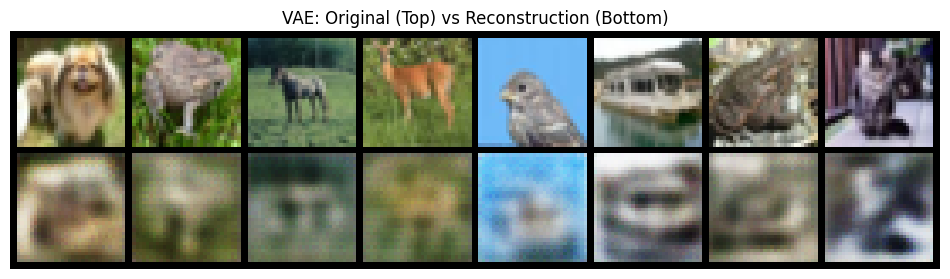

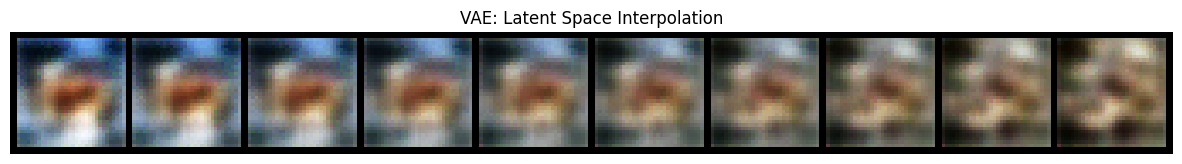

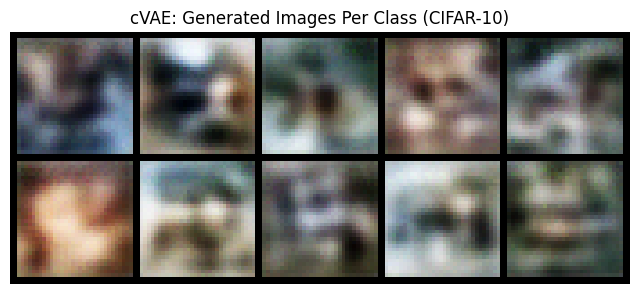

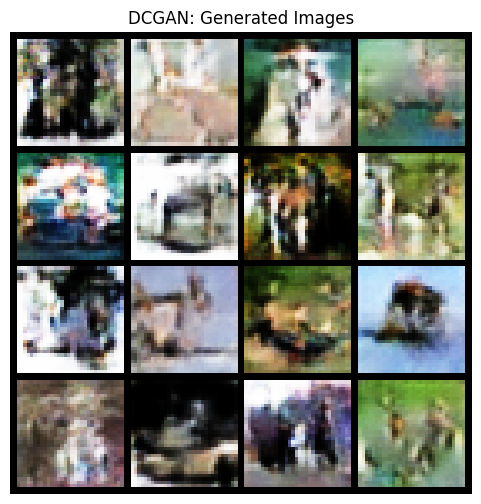

In [37]:
vae.eval()
cvae.eval()
netG.eval()

# 1. VAE: Original vs Reconstruction
sample_batch = next(iter(dataloader))[0][:8].to(device)
with torch.no_grad():
  recon, _, _ = vae(sample_batch)
grid_recon = vutils.make_grid(torch.cat([sample_batch.cpu(), recon.cpu()]), nrow=8, normalize=True)
plt.figure(figsize=(12,4))
plt.imshow(np.transpose(grid_recon.numpy(), (1,2,0)))
plt.title("VAE: Original (Top) vs Reconstruction (Bottom)")
plt.axis('off')
plt.show()

# 2. VAE: Latent Space Interpolation
with torch.no_grad():
  z1, z2 = torch.randn(1, nz).to(device), torch.randn(1, nz).to(device)
  alphas = np.linspace(0, 1, 10)
  imgs = []
  for a in alphas:
    z_interp = z1 * (1 - a) + z2 * a
    imgs.append(vae.decode(z_interp))
  grid_interp = vutils.make_grid(torch.cat(imgs), nrow=10, normalize=True)
plt.figure(figsize=(15,3))
plt.imshow(np.transpose(grid_interp.cpu().numpy(), (1,2,0)))
plt.title("VAE: Latent Space Interpolation")
plt.axis('off')
plt.show()

# 3. cVAE: Generated Images Per Class (CIFAR-10)
with torch.no_grad():
  z = torch.randn(num_classes, nz).to(device)
  labels = torch.arange(num_classes).to(device)
  samples = cvae.decode(z, labels)
grid_cvae = vutils.make_grid(samples, normalize=True, nrow=5)
plt.figure(figsize=(8,4))
plt.imshow(np.transpose(grid_cvae.cpu().numpy(), (1,2,0)))
plt.title("cVAE: Generated Images Per Class (CIFAR-10)")
plt.axis('off')
plt.show()

# 4. DCGAN: Generated Images
with torch.no_grad():
  noise = torch.randn(16, nz, 1, 1, device=device)
  fake_imgs = netG(noise)
grid_gan = vutils.make_grid(fake_imgs, normalize=True, nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_gan.cpu().numpy(), (1,2,0)))
plt.title("DCGAN: Generated Images")
plt.axis('off')
plt.show()